# Blocks in this notebook
* Random Baseline
* Heuristic Baseline
* Learning Rate Plots
* Combined Episode Reward Plot

In [2]:
!pip install -q tbparse matplotlib

In [1]:
# Random Baseline
import gymnasium as gym
import ale_py
import numpy as np

gym.register_envs(ale_py)

env = gym.make("PongNoFrameskip-v4")
returns = []

for episode in range(100):
    obs, info = env.reset(seed=episode)
    total_reward = 0
    done = False
    while not done:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    returns.append(total_reward)

print(f"Random Policy: {np.mean(returns):.1f} ± {np.std(returns)/np.sqrt(len(returns)):.1f}")
env.close()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Random Policy: -20.5 ± 0.1


In [2]:
# Heuristic Baseline
import gymnasium as gym
import ale_py
import numpy as np

gym.register_envs(ale_py)

env = gym.make("PongNoFrameskip-v4")
returns = []

def get_ball_and_paddle_y(obs):
    frame = obs[34:194, :, :]
    
    ball_mask = (frame[:, :, 0] > 200) & (frame[:, :, 1] > 200) & (frame[:, :, 2] > 200)
    ball_ys = np.where(ball_mask)[0]
    ball_y = np.mean(ball_ys) if len(ball_ys) > 0 else 80
    
    green_mask = (frame[:, :, 1] > 150) & (frame[:, :, 0] < 120) & (frame[:, :, 2] < 120)
    green_mask[:, :130] = False
    paddle_ys = np.where(green_mask)[0]
    paddle_y = np.mean(paddle_ys) if len(paddle_ys) > 0 else 80
    
    return ball_y, paddle_y

for episode in range(20):
    obs, info = env.reset(seed=episode)
    total_reward = 0
    done = False
    fire_pressed = False
    step = 0
    while not done:
        if not fire_pressed:
            action = 1
            fire_pressed = True
        elif step % 4 == 0:  # only check pixels every 4th frame
            ball_y, paddle_y = get_ball_and_paddle_y(obs)
            if ball_y < paddle_y - 2:
                action = 2
            elif ball_y > paddle_y + 2:
                action = 3
            else:
                action = 0
        
        obs, reward, terminated, truncated, info = env.step(action)
        if reward != 0:
            fire_pressed = False
        total_reward += reward
        done = terminated or truncated
        step += 1
    returns.append(total_reward)

print(f"\nHeuristic Policy: {np.mean(returns):.1f} ± {np.std(returns)/np.sqrt(len(returns)):.1f}")
env.close()


Heuristic Policy: -17.0 ± 0.0


# E1 Plot

2026-04-24 18:23:25.530303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777055005.685176      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777055005.729763      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777055006.084093      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777055006.084126      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777055006.084129      55 computation_placer.cc:177] computation placer alr

Found 5 tfevents files
  0_events.out.tfevents.1774966616.0b35639e6308.55.0: 1189 episodes, best=21
  1_events.out.tfevents.1774973328.054a826fcd6e.105.0: 988 episodes, best=21
  2_events.out.tfevents.1774977527.054a826fcd6e.105.1: 1136 episodes, best=21
  3_events.out.tfevents.1774973328.6c33c85f718b.153.0: 1257 episodes, best=21
  4_events.out.tfevents.1774977208.6c33c85f718b.153.1: 1244 episodes, best=21


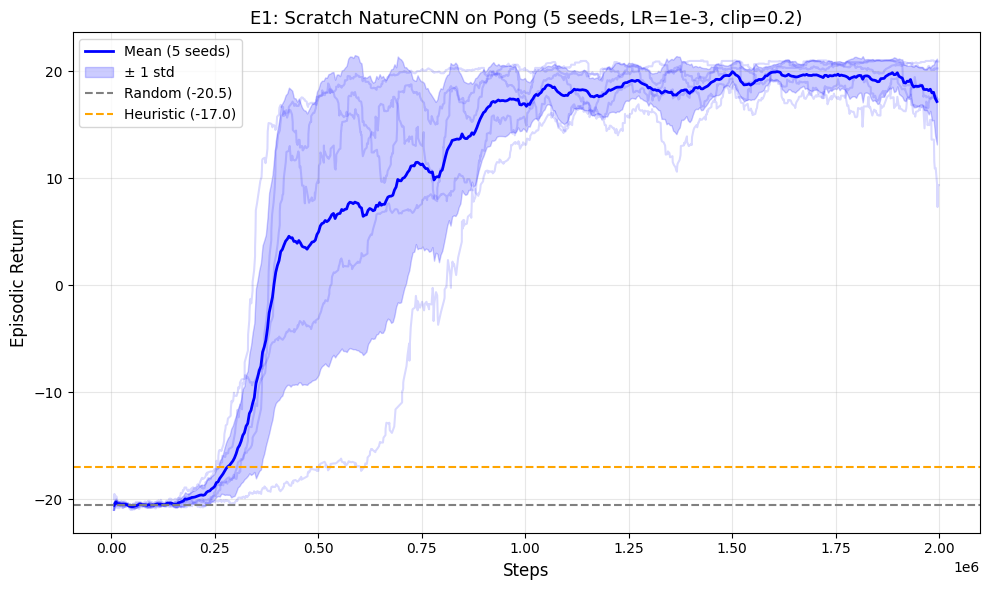


Final performance (last 10 episodes per seed):
  Seed 0: best=21, final_mean=19.9
  Seed 1: best=21, final_mean=17.9
  Seed 2: best=21, final_mean=17.0
  Seed 3: best=21, final_mean=8.3
  Seed 4: best=21, final_mean=20.8

Overall mean final: 16.8


In [3]:
# Learning Rate Plot
from tbparse import SummaryReader
import matplotlib.pyplot as plt
import numpy as np
import os

runs_dir = '/kaggle/input/datasets/yusufhilalll/naturecnn-final'  # wherever runs are stored

# Find all tfevents files
tf_files = sorted([f for f in os.listdir(runs_dir) if 'events' in f])
print(f"Found {len(tf_files)} tfevents files")

# Read all seeds
all_returns = []
for tf_file in tf_files:
    reader = SummaryReader(os.path.join(runs_dir, tf_file))
    df = reader.scalars
    returns = df[df['tag'] == 'charts/episodic_return'][['step', 'value']]
    all_returns.append(returns)
    print(f"  {tf_file}: {len(returns)} episodes, best={returns['value'].max():.0f}")

# Create common step axis and interpolate all seeds onto it
step_min = max(r['step'].min() for r in all_returns)
step_max = min(r['step'].max() for r in all_returns)
common_steps = np.linspace(step_min, step_max, 500)

interpolated = []
for returns in all_returns:
    # Smooth each seed first
    smoothed = returns['value'].rolling(window=20, min_periods=1).mean().values
    steps = returns['step'].values
    interp = np.interp(common_steps, steps, smoothed)
    interpolated.append(interp)

interpolated = np.array(interpolated)  # (5, 500)
mean_curve = interpolated.mean(axis=0)
std_curve = interpolated.std(axis=0)

# Plot
plt.figure(figsize=(10, 6))

# Individual seeds faded
for i, returns in enumerate(all_returns):
    smoothed = returns['value'].rolling(window=20, min_periods=1).mean()
    plt.plot(returns['step'], smoothed, alpha=0.15, color='blue')

# Mean ± std
plt.plot(common_steps, mean_curve, color='blue', linewidth=2, label='Mean (5 seeds)')
plt.fill_between(common_steps, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='blue', label='± 1 std')

# Baselines (From the Other Section)
plt.axhline(y=-20.5, color='gray', linestyle='--', linewidth=1.5, label='Random (-20.5)')
plt.axhline(y=-17.0, color='orange', linestyle='--', linewidth=1.5, label='Heuristic (-17.0)')

plt.xlabel('Steps', fontsize=12)
plt.ylabel('Episodic Return', fontsize=12)
plt.title('E1: Scratch NatureCNN on Pong (5 seeds, LR=1e-3, clip=0.2)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e1_final_learning_curve.png', dpi=150)
plt.show()

# Print summary
print(f"\nFinal performance (last 10 episodes per seed):")
for i, returns in enumerate(all_returns):
    final = returns['value'].tail(10).mean()
    best = returns['value'].max()
    print(f"  Seed {i}: best={best:.0f}, final_mean={final:.1f}")
print(f"\nOverall mean final: {np.mean([r['value'].tail(10).mean() for r in all_returns]):.1f}")

# E2 Plot

  train_log_seed0.csv: 1994 rows, best=13
  train_log_seed1.csv: 1994 rows, best=17
  train_log_seed2.csv: 1994 rows, best=-2
  train_log_seed3.csv: 1994 rows, best=3
  train_log_seed4.csv: 1994 rows, best=2


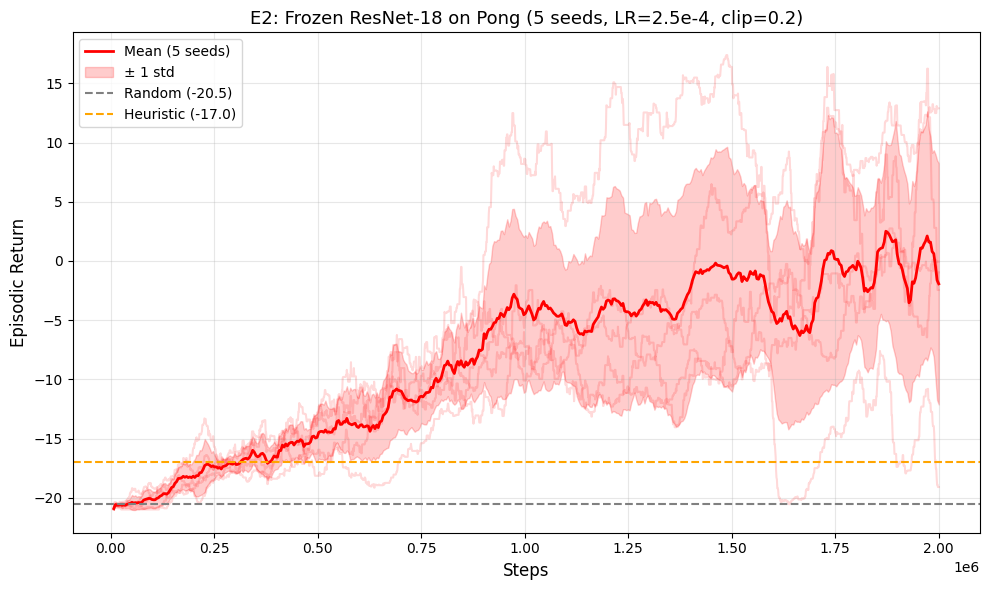

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Point to folder with all 5 seed CSVs
data_dir = '/kaggle/input/datasets/yusufhilalll/e2-dataa'

# Read all seeds
all_data = []
csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])

for csv_file in csv_files:
    df = pd.read_csv(os.path.join(data_dir, csv_file))
    df = df.dropna(subset=['recent_return_mean'])  # remove rows with no episodes
    all_data.append(df)
    print(f"  {csv_file}: {len(df)} rows, best={df['recent_return_mean'].max():.0f}")

# Interpolate onto common step axis
step_min = max(d['global_step'].min() for d in all_data)
step_max = min(d['global_step'].max() for d in all_data)
common_steps = np.linspace(step_min, step_max, 500)

interpolated = []
for df in all_data:
    interp = np.interp(common_steps, df['global_step'].values, df['recent_return_mean'].values)
    interpolated.append(interp)

interpolated = np.array(interpolated)
mean_curve = interpolated.mean(axis=0)
std_curve = interpolated.std(axis=0)

# Plot
plt.figure(figsize=(10, 6))

for df in all_data:
    plt.plot(df['global_step'], df['recent_return_mean'], alpha=0.15, color='red')

plt.plot(common_steps, mean_curve, color='red', linewidth=2, label='Mean (5 seeds)')
plt.fill_between(common_steps, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='red', label='± 1 std')

plt.axhline(y=-20.5, color='gray', linestyle='--', linewidth=1.5, label='Random (-20.5)')
plt.axhline(y=-17.0, color='orange', linestyle='--', linewidth=1.5, label='Heuristic (-17.0)')

plt.xlabel('Steps', fontsize=12)
plt.ylabel('Episodic Return', fontsize=12)
plt.title('E2: Frozen ResNet-18 on Pong (5 seeds, LR=2.5e-4, clip=0.2)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e2_final_learning_curve.png', dpi=150)
plt.show()

# E3 Plot

  train_log_seed0.csv: 1994 rows, best=9
  train_log_seed1.csv: 1994 rows, best=8
  train_log_seed2.csv: 1994 rows, best=-6
  train_log_seed3.csv: 1994 rows, best=15
  train_log_seed4.csv: 1994 rows, best=-17


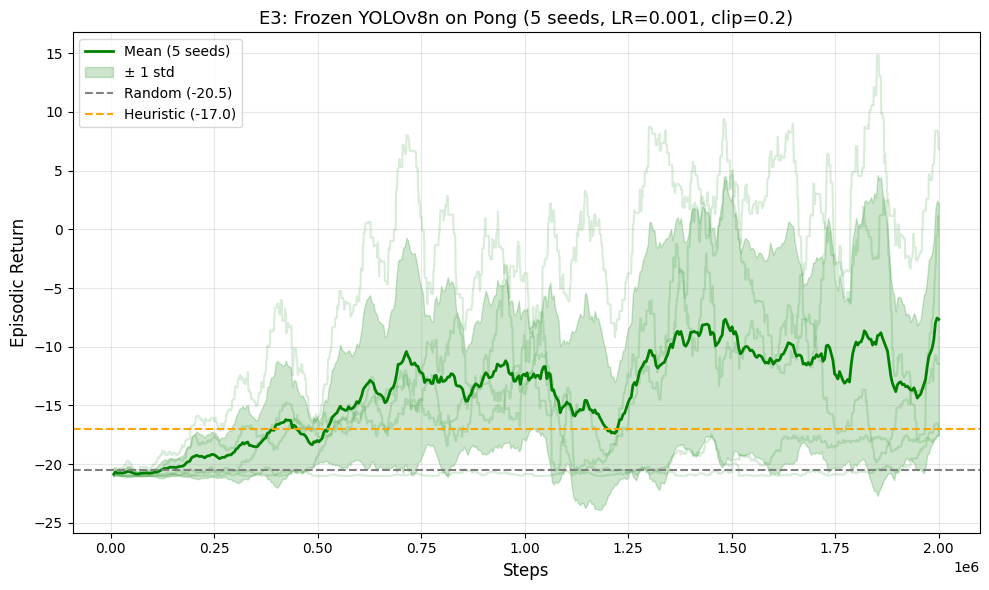

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Point to folder with all 5 seed CSVs
data_dir = '/kaggle/input/datasets/yusufhilalll/e2-data'  # named it wrong lol

# Read all seeds
all_data = []
csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])

for csv_file in csv_files:
    df = pd.read_csv(os.path.join(data_dir, csv_file))
    df = df.dropna(subset=['recent_return_mean'])  # remove rows with no episodes
    all_data.append(df)
    print(f"  {csv_file}: {len(df)} rows, best={df['recent_return_mean'].max():.0f}")

# Interpolate onto common step axis
step_min = max(d['global_step'].min() for d in all_data)
step_max = min(d['global_step'].max() for d in all_data)
common_steps = np.linspace(step_min, step_max, 500)

interpolated = []
for df in all_data:
    interp = np.interp(common_steps, df['global_step'].values, df['recent_return_mean'].values)
    interpolated.append(interp)

interpolated = np.array(interpolated)
mean_curve = interpolated.mean(axis=0)
std_curve = interpolated.std(axis=0)

# Plot
plt.figure(figsize=(10, 6))

for df in all_data:
    plt.plot(df['global_step'], df['recent_return_mean'], alpha=0.15, color='green')

plt.plot(common_steps, mean_curve, color='green', linewidth=2, label='Mean (5 seeds)')
plt.fill_between(common_steps, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='green', label='± 1 std')

plt.axhline(y=-20.5, color='gray', linestyle='--', linewidth=1.5, label='Random (-20.5)')
plt.axhline(y=-17.0, color='orange', linestyle='--', linewidth=1.5, label='Heuristic (-17.0)')

plt.xlabel('Steps', fontsize=12)
plt.ylabel('Episodic Return', fontsize=12)
plt.title('E3: Frozen YOLOv8n on Pong (5 seeds, LR=0.001, clip=0.2)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e3_final_learning_curve.png', dpi=150)
plt.show()

# E4 Plot

Found 3 tfevents files
  3_events.out.tfevents.1777024115.5302f3fa1f0f.55.0: 736 episodes, best=-11
  4_events.out.tfevents.1777024123.6750d3c85bc8.55.0: 724 episodes, best=-11
  events.out.tfevents.1776966642.199fcd8bb4a6.23.0: 732 episodes, best=-4


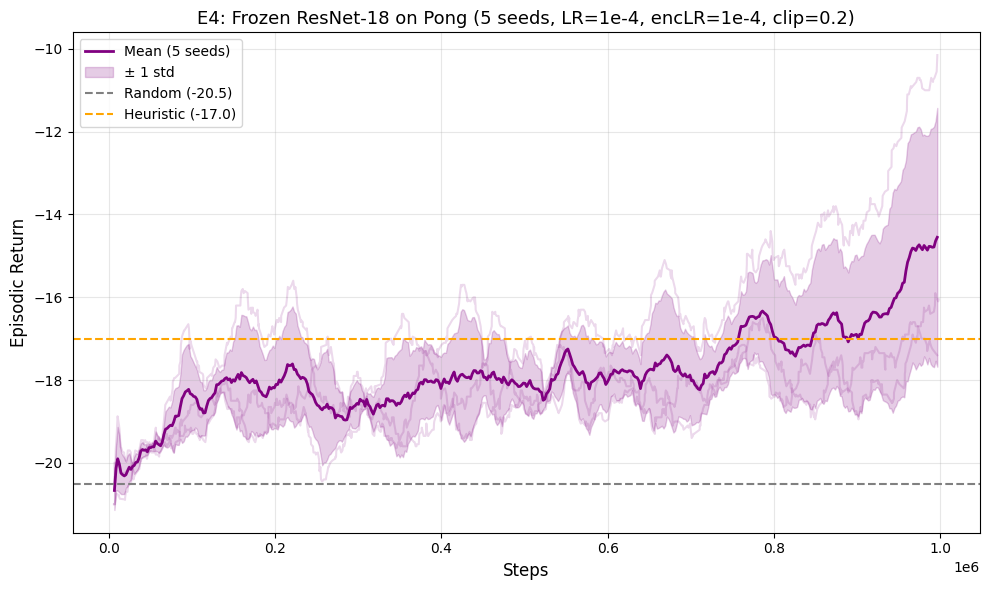


Final performance (last 10 episodes per seed):
  Seed 0: best=-11, final_mean=-15.2
  Seed 1: best=-11, final_mean=-17.6
  Seed 2: best=-4, final_mean=-9.5

Overall mean final: -14.1


In [12]:
# Learning Rate Plot
from tbparse import SummaryReader
import matplotlib.pyplot as plt
import numpy as np
import os

runs_dir = '/kaggle/input/datasets/yusufhilalll/e4-data'  # wherever runs are stored

# Find all tfevents files
tf_files = sorted([f for f in os.listdir(runs_dir) if 'events' in f])
print(f"Found {len(tf_files)} tfevents files")

# Read all seeds
all_returns = []
for tf_file in tf_files:
    reader = SummaryReader(os.path.join(runs_dir, tf_file))
    df = reader.scalars
    returns = df[df['tag'] == 'charts/episodic_return'][['step', 'value']]
    all_returns.append(returns)
    print(f"  {tf_file}: {len(returns)} episodes, best={returns['value'].max():.0f}")

# Create common step axis and interpolate all seeds onto it
step_min = max(r['step'].min() for r in all_returns)
step_max = min(r['step'].max() for r in all_returns)
common_steps = np.linspace(step_min, step_max, 500)

interpolated = []
for returns in all_returns:
    # Smooth each seed first
    smoothed = returns['value'].rolling(window=20, min_periods=1).mean().values
    steps = returns['step'].values
    interp = np.interp(common_steps, steps, smoothed)
    interpolated.append(interp)

interpolated = np.array(interpolated)  # (5, 500)
mean_curve = interpolated.mean(axis=0)
std_curve = interpolated.std(axis=0)

# Plot
plt.figure(figsize=(10, 6))

# Individual seeds faded
for i, returns in enumerate(all_returns):
    smoothed = returns['value'].rolling(window=20, min_periods=1).mean()
    plt.plot(returns['step'], smoothed, alpha=0.15, color='purple')

# Mean ± std
plt.plot(common_steps, mean_curve, color='purple', linewidth=2, label='Mean (5 seeds)')
plt.fill_between(common_steps, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='purple', label='± 1 std')

# Baselines (From the Other Section)
plt.axhline(y=-20.5, color='gray', linestyle='--', linewidth=1.5, label='Random (-20.5)')
plt.axhline(y=-17.0, color='orange', linestyle='--', linewidth=1.5, label='Heuristic (-17.0)')

plt.xlabel('Steps', fontsize=12)
plt.ylabel('Episodic Return', fontsize=12)
plt.title('E4: Frozen ResNet-18 on Pong (5 seeds, LR=1e-4, encLR=1e-4, clip=0.2)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('e4_final_learning_curve.png', dpi=150)
plt.show()

# Print summary
print(f"\nFinal performance (last 10 episodes per seed):")
for i, returns in enumerate(all_returns):
    final = returns['value'].tail(10).mean()
    best = returns['value'].max()
    print(f"  Seed {i}: best={best:.0f}, final_mean={final:.1f}")
print(f"\nOverall mean final: {np.mean([r['value'].tail(10).mean() for r in all_returns]):.1f}")

# Combined Plot

Encoder                          Mean Final      ± Std  Seeds
------------------------------------------------------------
E1: Scratch CNN                        17.0        2.3      5
E2: Frozen ResNet-18                   -4.0        6.5      5
E3: Frozen YOLOv8n                    -12.6        5.7      5
E4: Fine-tuned ResNet-18              -14.6        3.1      3


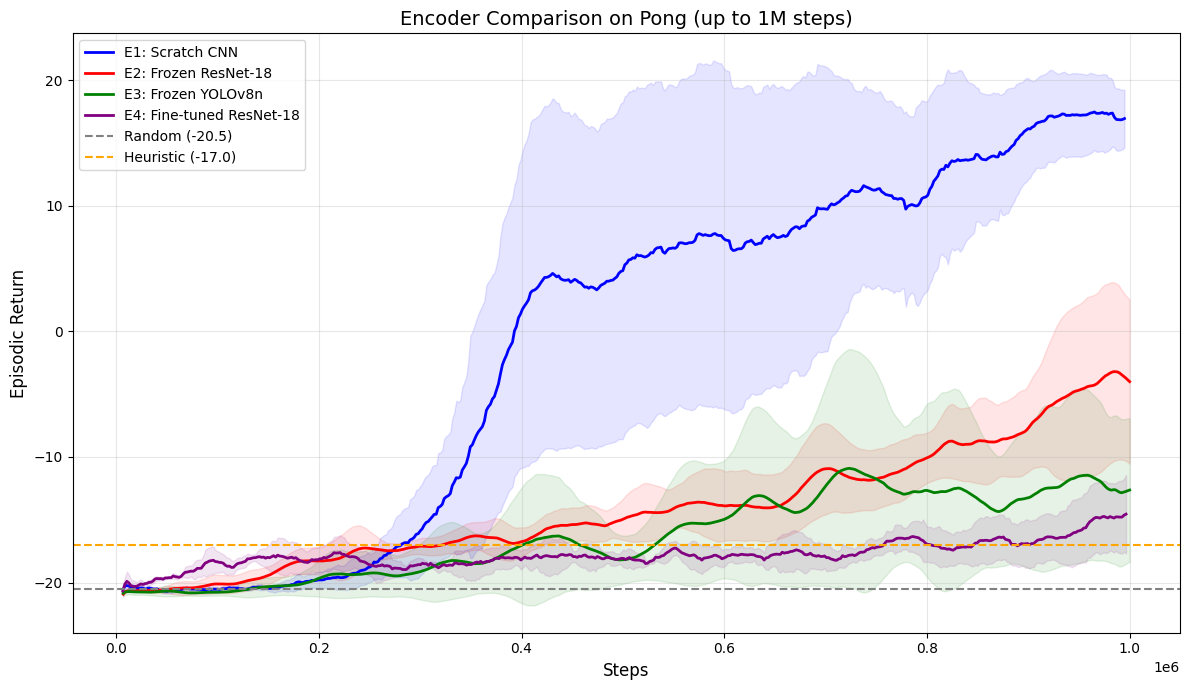

In [13]:
from tbparse import SummaryReader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================
# Load E1 (tfevents)
# ============================================
e1_dir = '/kaggle/input/datasets/yusufhilalll/naturecnn-final' 
tf_files = sorted([f for f in os.listdir(e1_dir) if 'events' in f])
e1_returns = []
for tf_file in tf_files:
    reader = SummaryReader(os.path.join(e1_dir, tf_file))
    df = reader.scalars
    returns = df[df['tag'] == 'charts/episodic_return'][['step', 'value']]
    e1_returns.append(returns)

# ============================================
# Load E2 (CSVs)
# ============================================
e2_dir = '/kaggle/input/datasets/yusufhilalll/e2-dataa' 
e2_returns = []
for csv_file in sorted([f for f in os.listdir(e2_dir) if f.endswith('.csv')]):
    df = pd.read_csv(os.path.join(e2_dir, csv_file))
    df = df.dropna(subset=['recent_return_mean'])
    returns = df[['global_step', 'recent_return_mean']].rename(
        columns={'global_step': 'step', 'recent_return_mean': 'value'})
    e2_returns.append(returns)

# ============================================
# Load E3 (CSVs — same format as E2)
# ============================================
e3_dir = '/kaggle/input/datasets/yusufhilalll/e2-data'
e3_returns = []
for csv_file in sorted([f for f in os.listdir(e3_dir) if f.endswith('.csv')]):
    df = pd.read_csv(os.path.join(e3_dir, csv_file))
    df = df.dropna(subset=['recent_return_mean'])
    returns = df[['global_step', 'recent_return_mean']].rename(
        columns={'global_step': 'step', 'recent_return_mean': 'value'})
    e3_returns.append(returns)

# ============================================
# Load E4 (tfevents — skip seeds with < 50 episodes)
# ============================================
e4_dir = '/kaggle/input/datasets/yusufhilalll/e4-data'
tf_files = sorted([f for f in os.listdir(e4_dir) if 'events' in f])
e4_returns = []
for tf_file in tf_files:
    reader = SummaryReader(os.path.join(e4_dir, tf_file))
    df = reader.scalars
    returns = df[df['tag'] == 'charts/episodic_return'][['step', 'value']]
    if len(returns) >= 50:
        e4_returns.append(returns)

# ============================================
# Helper: compute mean curve up to 1M steps
# ============================================
def compute_mean_std(all_returns, max_step=1_000_000, n_points=500, smooth_window=20):
    # Filter to max_step
    filtered = []
    for r in all_returns:
        r = r[r['step'] <= max_step]
        if len(r) > smooth_window:
            filtered.append(r)
    
    step_min = max(r['step'].min() for r in filtered)
    step_max = min(r['step'].max() for r in filtered)
    common_steps = np.linspace(step_min, step_max, n_points)
    
    interpolated = []
    for r in filtered:
        smoothed = r['value'].rolling(window=smooth_window, min_periods=1).mean().values
        interp = np.interp(common_steps, r['step'].values, smoothed)
        interpolated.append(interp)
    
    interpolated = np.array(interpolated)
    return common_steps, interpolated.mean(axis=0), interpolated.std(axis=0)

# ============================================
# Plot all four on one graph
# ============================================
plt.figure(figsize=(12, 7))

encoders = [
    ('E1: Scratch CNN', e1_returns, 'blue'),
    ('E2: Frozen ResNet-18', e2_returns, 'red'),
    ('E3: Frozen YOLOv8n', e3_returns, 'green'),
    ('E4: Fine-tuned ResNet-18', e4_returns, 'purple'),
]

print(f"{'Encoder':<30} {'Mean Final':>12} {'± Std':>10} {'Seeds':>6}")
print("-" * 60)

for name, data, color in encoders:
    steps, mean, std = compute_mean_std(data)
    plt.plot(steps, mean, color=color, linewidth=2, label=name)
    plt.fill_between(steps, mean - std, mean + std, alpha=0.1, color=color)
    
    # Report final mean ± std
    final_mean = mean[-1]
    final_std = std[-1]
    print(f"{name:<30} {final_mean:>12.1f} {final_std:>10.1f} {len(data):>6}")

# Baselines
plt.axhline(y=-20.5, color='gray', linestyle='--', linewidth=1.5, label='Random (-20.5)')
plt.axhline(y=-17.0, color='orange', linestyle='--', linewidth=1.5, label='Heuristic (-17.0)')

plt.xlabel('Steps', fontsize=12)
plt.ylabel('Episodic Return', fontsize=12)
plt.title('Encoder Comparison on Pong (up to 1M steps)', fontsize=14)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_encoders_comparison.png', dpi=200)
plt.show()